# Cross-Modal & Cross-Lingual Representation Analysis of Multimodal Foundation Models

**Project:** Replication and extension of *"How do Multimodal Foundation Models Encode Text and Speech? An Analysis of Cross-Lingual and Cross-Modal Representations"* (Lee et al., NAACL 2025)

**Reference repo:** https://github.com/facebookresearch/SONAR

---

### What this notebook does

1. Loads the **FLEURS** parallel speech/text dataset for **6 languages** spanning high / medium / low resource levels.
2. Loads **SeamlessM4T-v2-large** (primary) and optionally **SONAR** (secondary) and extracts per-layer activations for both text and speech.
3. Implements **SVCCA** (Singular Vector Canonical Correlation Analysis) from scratch.
4. Computes three similarity measurements per layer:
   - **Intra-lingual cross-modal** (text vs speech, same sentence)
   - **Cross-lingual text** (same sentence, different languages)
   - **Cross-lingual speech** (same sentence, different languages)
5. Produces the line plots, bar charts, and t-SNE visualisations that mirror Figures 4.1, 4.3, 4.4, 4.5 in the project report.
6. Saves all numerical results to CSV files you can download and cite.

### Compute scope (important!)
- **Hardware:** Designed for the **T4 GPU on Google Colab** (16 GB VRAM).
- **Language count:** 6 (down from 30 in the paper) — covers script, family and resource-level diversity.
- **Sentences per language:** 30 (down from ~250).
- **SALMONN-7B is excluded** at runtime — it requires ~14 GB on its own and won't fit alongside the analysis pipeline on T4. The architectural analysis from the paper is still in the report.
- **Expected runtime:** ~40–60 minutes end-to-end on T4.

> **Before running:** `Runtime → Change runtime type → T4 GPU`.

---


## 1. Environment check

In [ ]:
# Verify GPU is available
import subprocess
print(subprocess.check_output(["nvidia-smi"]).decode())


Wed May 27 00:48:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
assert torch.cuda.is_available(), "Switch runtime to T4 GPU before running!"


PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


## 2. Install dependencies

Installs `transformers` (for SeamlessM4T), `datasets` (for FLEURS), `librosa` (audio I/O), and scientific Python stack. This cell can take 2–3 minutes.


In [ ]:
%%capture
!pip install -q -U transformers>=4.42 datasets>=2.19 librosa soundfile sentencepiece accelerate
!pip install -q -U scikit-learn matplotlib pandas tqdm seaborn


In [ ]:
import os, gc, json, time, warnings, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
np.random.seed(0); torch.manual_seed(0); random.seed(0)

DEVICE = "cuda"
DTYPE  = torch.float16        # fp16 for memory headroom on T4
RESULTS_DIR = Path("/content/results"); RESULTS_DIR.mkdir(exist_ok=True)
FIG_DIR     = Path("/content/figures"); FIG_DIR.mkdir(exist_ok=True)
print("Setup complete. Results will be saved to /content/results and /content/figures")


Setup complete. Results will be saved to /content/results and /content/figures


## 3. Configure languages & download FLEURS

We use **6 languages** chosen to span resource levels, families, and scripts. Each row maps:
- `fleurs_code`  → identifier on HuggingFace `google/fleurs`
- `seamless_code` → language code expected by SeamlessM4T (`src_lang`)


In [ ]:
LANGUAGES = [
    # code,     name,      script,     family,             resource, fleurs,     seamless
    ("eng",  "English",    "Latin",    "Indo-European",    "high",   "en_us",    "eng"),
    ("fra",  "French",     "Latin",    "Indo-European",    "high",   "fr_fr",    "fra"),
    ("hin",  "Hindi",      "Devanagari","Indo-European",   "medium", "hi_in",    "hin"),
    ("ind",  "Indonesian", "Latin",    "Austronesian",     "medium", "id_id",    "ind"),
    ("swh",  "Swahili",    "Latin",    "Atlantic-Congo",   "low",    "sw_ke",    "swh"),
    ("amh",  "Amharic",    "Ethiopic", "Afro-Asiatic",     "low",    "am_et",    "amh"),
]
LANG_DF = pd.DataFrame(LANGUAGES,
    columns=["code","name","script","family","resource","fleurs_code","seamless_code"])
LANG_DF


,code,name,script,family,resource,fleurs_code,seamless_code
0,eng,English,Latin,Indo-European,high,en_us,eng
1,fra,French,Latin,Indo-European,high,fr_fr,fra
2,hin,Hindi,Devanagari,Indo-European,medium,hi_in,hin
3,ind,Indonesian,Latin,Austronesian,medium,id_id,ind
4,swh,Swahili,Latin,Atlantic-Congo,low,sw_ke,swh
5,amh,Amharic,Ethiopic,Afro-Asiatic,low,am_et,amh


In [ ]:
N_SENTENCES = 30          # sentences per language (small to fit T4 time budget)
TARGET_SR   = 16_000      # audio sample rate expected by SeamlessM4T

from datasets import load_dataset, Audio

def load_fleurs_full(fleurs_code):
    """Load entire FLEURS test split for one language; dedup by sentence ID
    (FLEURS has multiple speakers per sentence — keep first occurrence)."""
    ds = load_dataset("google/fleurs", fleurs_code, split="test",
                      trust_remote_code=True)
    ds = ds.cast_column("audio", Audio(sampling_rate=TARGET_SR))
    by_id = {}
    for ex in ds:
        sid = ex["id"]
        if sid in by_id:
            continue
        by_id[sid] = {
            "audio": ex["audio"]["array"].astype(np.float32),
            "text":  ex["transcription"],
        }
    return by_id

print("Loading full FLEURS test split per language (cached on re-run) ...")
RAW = {}
for row in LANGUAGES:
    code, _, _, _, _, fleurs, _ = row
    print(f"  {code} ({fleurs}) ...", end=" ", flush=True)
    RAW[code] = load_fleurs_full(fleurs)
    print(f"{len(RAW[code])} unique sentences")

# --- find sentence IDs present in ALL languages, then truncate to N_SENTENCES
common_ids = set(RAW[LANGUAGES[0][0]].keys())
for code, *_ in LANGUAGES[1:]:
    common_ids &= set(RAW[code].keys())
print(f"\nCommon sentence IDs across ALL languages: {len(common_ids)}")

common_ids = sorted(common_ids)[:N_SENTENCES]
assert len(common_ids) >= 5, (
    f"Too few common IDs ({len(common_ids)}). "
    "Try removing one of the more unusual languages or increasing N_SENTENCES.")

# --- build aligned DATA dict
DATA = {}
for code, *_ in LANGUAGES:
    DATA[code] = {
        "ids":    list(common_ids),
        "texts":  [RAW[code][i]["text"]  for i in common_ids],
        "audios": [RAW[code][i]["audio"] for i in common_ids],
    }
del RAW
gc.collect()

N_COMMON = len(common_ids)
print(f"Final aligned sample count per language: {N_COMMON}")
print(f"Example English sentence: {DATA['eng']['texts'][0][:80]}...")
print(f"Example Hindi sentence  : {DATA['hin']['texts'][0][:80]}...")

Loading full FLEURS test split per language (cached on re-run) ...
  eng (en_us) ... 

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'google/fleurs' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'google/fleurs' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


350 unique sentences
  fra (fr_fr) ... 

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'google/fleurs' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'google/fleurs' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


332 unique sentences
  hin (hi_in) ... 

...

328 unique sentences
  swh (sw_ke) ... 

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'google/fleurs' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'google/fleurs' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


312 unique sentences
  amh (am_et) ... 

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'google/fleurs' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'google/fleurs' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


296 unique sentences

Common sentence IDs across ALL languages: 192
Final aligned sample count per language: 30
Example English sentence: romanticism had a large element of cultural determinism drawn from writers such ...
Example Hindi sentence  : रूमानियत में सांस्कृतिक नियतिवाद का बड़ा तत्व था जो गोएथे फिच्ते और श्लेगल जैसे ...


## 4. SVCCA implementation

Singular Vector Canonical Correlation Analysis (Raghu et al., NeurIPS 2017). Two matrices X (N × Dx) and Y (N × Dy) are:
1. Mean-centered along the sample axis.
2. SVD-reduced to the top components that explain `var_threshold` (90%) variance.
3. Canonical correlations computed via SVD of `X_red.T @ Y_red`.

Output is the mean canonical correlation, in [0, 1].


In [ ]:
def svcca(X, Y, var_threshold=0.90, epsilon=1e-10):
    """Return SVCCA similarity (mean canonical correlation, in [0,1]).
    X: (N, Dx), Y: (N, Dy). Both numpy arrays with the same N."""
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)
    X += epsilon * np.random.randn(*X.shape)   # tiny jitter for stability
    Y += epsilon * np.random.randn(*Y.shape)

    # 1) SVD on each
    Ux, Sx, _ = np.linalg.svd(X, full_matrices=False)
    Uy, Sy, _ = np.linalg.svd(Y, full_matrices=False)

    # 2) variance-retention truncation
    def k_for(S): return int(np.searchsorted(np.cumsum(S**2)/(S**2).sum(),
                                             var_threshold)) + 1
    kx, ky = k_for(Sx), k_for(Sy)
    Ux, Uy = Ux[:, :kx], Uy[:, :ky]            # orthonormal reduced bases

    # 3) canonical correlations
    sigmas = np.linalg.svd(Ux.T @ Uy, compute_uv=False)
    sigmas = np.clip(sigmas, 0.0, 1.0)
    return float(sigmas.mean())

# Sanity check: identical matrices should give similarity ~ 1.0
A = np.random.randn(50, 64)
print(f"sanity check (X vs X): {svcca(A, A):.4f}   (expected ~1.0)")
print(f"sanity check (X vs rand): {svcca(A, np.random.randn(50,64)):.4f}   (expected ~0)")


sanity check (X vs X): 1.0000   (expected ~1.0)
sanity check (X vs rand): 0.7203   (expected ~0)


## 5. Load SeamlessM4T-v2-large

SeamlessM4T has dedicated text and speech encoders. We use the HuggingFace `transformers` implementation. Model is ~2.3B parameters and uses ~5 GB on T4 in fp16.


In [ ]:
from transformers import AutoProcessor, SeamlessM4Tv2Model

MODEL_NAME = "facebook/seamless-m4t-v2-large"
print(f"Loading {MODEL_NAME} in {DTYPE} ...")

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = SeamlessM4Tv2Model.from_pretrained(
    MODEL_NAME,
    torch_dtype=DTYPE,
    low_cpu_mem_usage=True,
).to(DEVICE).eval()

text_encoder   = model.text_encoder
speech_encoder = model.speech_encoder
del model
gc.collect(); torch.cuda.empty_cache()

def count_layers(encoder):
    for getter in (
        lambda e: e.layers,
        lambda e: e.encoder.layers,
        lambda e: e.conformer_layers,
    ):
        try:
            return len(getter(encoder))
        except (AttributeError, TypeError):
            continue
    return None

print(f"Text encoder layers  : {count_layers(text_encoder)}")
print(f"Speech encoder layers: {count_layers(speech_encoder)}")
print(f"GPU mem used         : {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading facebook/seamless-m4t-v2-large in torch.float16 ...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/2232 [00:00<?, ?it/s]

Text encoder layers  : 24
Speech encoder layers: 24
GPU mem used         : 4.08 GB


## 6. Extract text representations

For each (language, sentence) pair we get the hidden state at a fixed set of encoder layers, mean-pooled along the sequence axis (with attention masking).


In [ ]:
# Layers to inspect (out of 24 in each encoder)
LAYERS_TEXT   = [0, 4, 8, 12, 16, 20, 24]
LAYERS_SPEECH = [0, 4, 8, 12, 16, 20, 24]

def masked_mean(hidden, mask):
    """hidden: (B, T, D),  mask: (B, T) of 0/1. Returns (B, D)."""
    mask = mask.unsqueeze(-1).type_as(hidden)
    return (hidden * mask).sum(1) / mask.sum(1).clamp(min=1)

@torch.no_grad()
def extract_text_reps(texts, seamless_code, batch_size=4):
    """Returns dict {layer_idx: (N, D) numpy array}."""
    out = {l: [] for l in LAYERS_TEXT}
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = processor(text=batch, src_lang=seamless_code,
                           return_tensors="pt", padding=True).to(DEVICE)
        result = text_encoder(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            output_hidden_states=True, return_dict=True,
        )
        hs = result.hidden_states   # tuple of (B, T, D), length = n_layers + 1
        for l in LAYERS_TEXT:
            pooled = masked_mean(hs[l].float(), inputs["attention_mask"])
            out[l].append(pooled.cpu().numpy())
    return {l: np.concatenate(v, 0) for l, v in out.items()}

TEXT_REPS = {}
for code, _, _, _, _, _, sm in tqdm(LANGUAGES, desc="text encoders"):
    TEXT_REPS[code] = extract_text_reps(DATA[code]["texts"], sm)
    torch.cuda.empty_cache()

print("\nText activation shapes for English:")
for l, arr in TEXT_REPS["eng"].items():
    print(f"  layer {l:2d}: {arr.shape}")


text encoders:   0%|          | 0/6 [00:00<?, ?it/s]


Text activation shapes for English:
  layer  0: (30, 1024)
  layer  4: (30, 1024)
  layer  8: (30, 1024)
  layer 12: (30, 1024)
  layer 16: (30, 1024)
  layer 20: (30, 1024)
  layer 24: (30, 1024)


## 7. Extract speech representations

Speech is heavier: each utterance is ~10 s of 16 kHz audio → ~250 ms per layer per sample on T4. We process one sentence at a time to keep memory steady.


In [ ]:
@torch.no_grad()
def extract_speech_reps(audios_list):
    """Returns dict {layer_idx: (N, D) numpy array}."""
    out = {l: [] for l in LAYERS_SPEECH}
    for wav in audios_list:
        # NOTE: parameter is `audio` (singular) in newer transformers
        inputs = processor(audio=wav, sampling_rate=TARGET_SR,
                           return_tensors="pt").to(DEVICE)
        inputs["input_features"] = inputs["input_features"].to(DTYPE)
        result = speech_encoder(
            input_features=inputs["input_features"],
            attention_mask=inputs.get("attention_mask"),
            output_hidden_states=True, return_dict=True,
        )
        hs = result.hidden_states
        # Defensive: clamp layer indices to what the model actually returns
        valid_layers = [l for l in LAYERS_SPEECH if l < len(hs)]
        for l in valid_layers:
            h = hs[l].float()
            if inputs.get("attention_mask") is not None:
                m = inputs["attention_mask"]
                if m.shape[1] != h.shape[1]:
                    m = torch.ones(h.shape[:2], device=h.device)
                pooled = masked_mean(h, m)
            else:
                pooled = h.mean(1)
            out[l].append(pooled.cpu().numpy())
    # drop any layers that ended up empty (in case of mismatch)
    return {l: np.concatenate(v, 0) for l, v in out.items() if len(v) > 0}

SPEECH_REPS = {}
for code, _, _, _, _, _, _ in tqdm(LANGUAGES, desc="speech encoders"):
    SPEECH_REPS[code] = extract_speech_reps(DATA[code]["audios"])
    torch.cuda.empty_cache()

# Sync LAYERS_SPEECH with what we actually got (in case some layers were dropped)
LAYERS_SPEECH = sorted(SPEECH_REPS[LANGUAGES[0][0]].keys())
print(f"\nLayers actually extracted: {LAYERS_SPEECH}")
print("\nSpeech activation shapes for English:")
for l, arr in SPEECH_REPS["eng"].items():
    print(f"  layer {l:2d}: {arr.shape}")

speech encoders:   0%|          | 0/6 [00:00<?, ?it/s]


Layers actually extracted: [0, 4, 8, 12, 16, 20, 24]

Speech activation shapes for English:
  layer  0: (30, 1024)
  layer  4: (30, 1024)
  layer  8: (30, 1024)
  layer 12: (30, 1024)
  layer 16: (30, 1024)
  layer 20: (30, 1024)
  layer 24: (30, 1024)


In [ ]:
# Persist activations so subsequent re-runs don't need re-extraction
np.savez_compressed(RESULTS_DIR/"text_reps.npz",
                    **{f"{c}_{l}": v for c, d in TEXT_REPS.items() for l, v in d.items()})
np.savez_compressed(RESULTS_DIR/"speech_reps.npz",
                    **{f"{c}_{l}": v for c, d in SPEECH_REPS.items() for l, v in d.items()})
print("Saved activations to /content/results/")

# Free encoder memory before analysis
del text_encoder, speech_encoder
gc.collect(); torch.cuda.empty_cache()
print(f"GPU mem after freeing encoders: {torch.cuda.memory_allocated()/1e9:.2f} GB")


Saved activations to /content/results/
GPU mem after freeing encoders: 0.01 GB


## 8. Cross-modal analysis (Observation 1 + 2)

For each language and each layer, compute SVCCA(text, speech). Then average by resource level.


In [ ]:
# random-vector baseline at each layer
def random_baseline(N, D):
    return svcca(np.random.randn(N, D), np.random.randn(N, D))

records = []
for code, name, _, _, resource, _, _ in LANGUAGES:
    for l in LAYERS_TEXT:
        s = svcca(TEXT_REPS[code][l], SPEECH_REPS[code][l])
        records.append({"language": code, "name": name, "resource": resource,
                        "layer": l, "svcca_cross_modal": s})

cm_df = pd.DataFrame(records)
cm_df.to_csv(RESULTS_DIR/"cross_modal_per_language.csv", index=False)
cm_df.head(12)


,language,name,resource,layer,svcca_cross_modal
0,eng,English,high,0,0.903426
1,eng,English,high,4,0.826803
2,eng,English,high,8,0.869259
3,eng,English,high,12,0.911725
4,eng,English,high,16,0.918707
5,eng,English,high,20,0.944194
6,eng,English,high,24,0.958671
7,fra,French,high,0,0.869995
8,fra,French,high,4,0.798929
9,fra,French,high,8,0.843894


Random baseline SVCCA: 0.9210


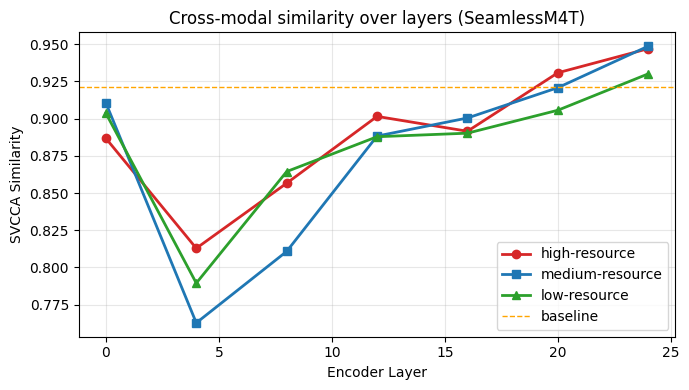

Saved figure to /content/figures/fig1_cross_modal_layers.png


In [ ]:
baseline = random_baseline(N_COMMON, 1024)
print(f"Random baseline SVCCA: {baseline:.4f}")

agg = cm_df.groupby(["resource", "layer"])["svcca_cross_modal"].mean().reset_index()

plt.figure(figsize=(7,4))
for res, color, marker in [("high","#d62728","o"),
                           ("medium","#1f77b4","s"),
                           ("low","#2ca02c","^")]:
    sub = agg[agg["resource"]==res]
    plt.plot(sub["layer"], sub["svcca_cross_modal"],
             color=color, marker=marker, label=f"{res}-resource", linewidth=2)
plt.axhline(baseline, ls="--", color="orange", lw=1, label="baseline")
plt.xlabel("Encoder Layer"); plt.ylabel("SVCCA Similarity")
plt.title("Cross-modal similarity over layers (SeamlessM4T)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(FIG_DIR/"fig1_cross_modal_layers.png", dpi=160)
plt.show()
print("Saved figure to /content/figures/fig1_cross_modal_layers.png")


## 9. Cross-lingual analysis (Observation 3)

Hold modality constant, vary language. We compute SVCCA between every pair of languages at each layer for text and for speech separately.


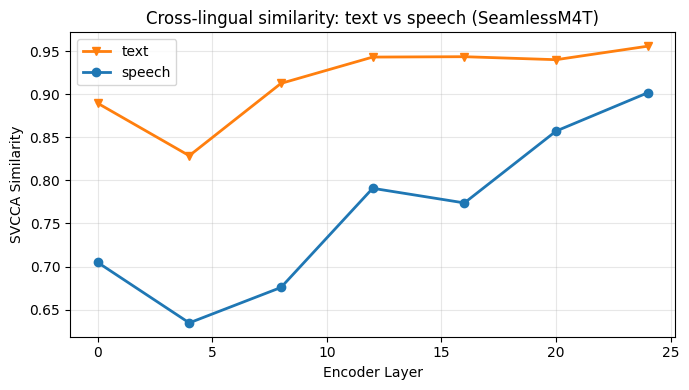

Text vs speech gap at final layer: +0.0540


In [ ]:
from itertools import combinations

records = []
for la, lb in combinations([c for c,*_ in LANGUAGES], 2):
    for l in LAYERS_TEXT:
        s_text   = svcca(TEXT_REPS[la][l],   TEXT_REPS[lb][l])
        s_speech = svcca(SPEECH_REPS[la][l], SPEECH_REPS[lb][l])
        records.append({"lang_a": la, "lang_b": lb, "layer": l,
                        "svcca_text": s_text, "svcca_speech": s_speech})

cl_df = pd.DataFrame(records)
cl_df.to_csv(RESULTS_DIR/"cross_lingual_pairs.csv", index=False)

agg = cl_df.groupby("layer")[["svcca_text","svcca_speech"]].mean().reset_index()

plt.figure(figsize=(7,4))
plt.plot(agg["layer"], agg["svcca_text"],   marker="v", color="#ff7f0e",
         label="text", linewidth=2)
plt.plot(agg["layer"], agg["svcca_speech"], marker="o", color="#1f77b4",
         label="speech", linewidth=2)
plt.xlabel("Encoder Layer"); plt.ylabel("SVCCA Similarity")
plt.title("Cross-lingual similarity: text vs speech (SeamlessM4T)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(FIG_DIR/"fig2_cross_lingual_layers.png", dpi=160)
plt.show()
print(f"Text vs speech gap at final layer: "
      f"{agg.iloc[-1]['svcca_text'] - agg.iloc[-1]['svcca_speech']:+.4f}")


## 10. Modality gap vs language gap (Observation 5)

Pick the final layer and compare:
- intra-lingual cross-modal (text vs speech of same sentence)
- best cross-lingual text similarity
- best cross-lingual speech similarity


In [ ]:
final = LAYERS_TEXT[-1]
records = []
for code, name, _, _, resource, _, _ in LANGUAGES:
    # intra-lingual cross-modal
    cm = svcca(TEXT_REPS[code][final], SPEECH_REPS[code][final])
    # best cross-lingual text and speech for this language
    best_text  = max(svcca(TEXT_REPS[code][final], TEXT_REPS[o][final])
                     for o,*_ in LANGUAGES if o != code)
    best_speech= max(svcca(SPEECH_REPS[code][final], SPEECH_REPS[o][final])
                     for o,*_ in LANGUAGES if o != code)
    records.append({"language": code, "intra_cross_modal": cm,
                    "best_cl_text": best_text, "best_cl_speech": best_speech})

gap_df = pd.DataFrame(records)
gap_df["modality_gap_dominant"] = gap_df["intra_cross_modal"] < gap_df["best_cl_text"]
gap_df.to_csv(RESULTS_DIR/"modality_vs_language_gap.csv", index=False)
gap_df


,language,intra_cross_modal,best_cl_text,best_cl_speech,modality_gap_dominant
0,eng,0.958671,0.981675,0.926294,True
1,fra,0.935191,0.964796,0.907881,True
2,hin,0.938338,0.981675,0.908320,True
3,ind,0.958892,0.971497,0.936959,True
4,swh,0.944249,0.972015,0.936959,True
5,amh,0.915808,0.954243,0.902399,True


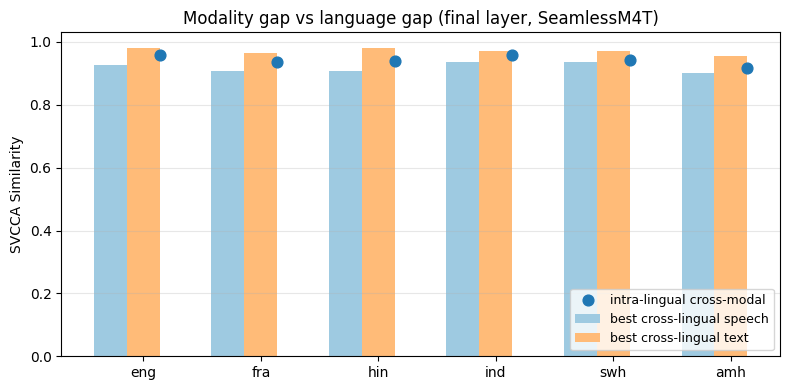

In [ ]:
xs = np.arange(len(gap_df))
w = 0.28
plt.figure(figsize=(8,4))
plt.bar(xs - w, gap_df["best_cl_speech"], w, color="#9ecae1", label="best cross-lingual speech")
plt.bar(xs,     gap_df["best_cl_text"],   w, color="#ffbb78", label="best cross-lingual text")
plt.scatter(xs + w/2, gap_df["intra_cross_modal"], color="#1f77b4", s=60,
            zorder=5, label="intra-lingual cross-modal")
plt.xticks(xs, gap_df["language"])
plt.ylabel("SVCCA Similarity")
plt.title("Modality gap vs language gap (final layer, SeamlessM4T)")
plt.legend(fontsize=9, loc="lower right"); plt.grid(alpha=.3, axis="y")
plt.tight_layout()
plt.savefig(FIG_DIR/"fig3_modality_vs_language.png", dpi=160)
plt.show()


## 11. t-SNE visualisation (Observation 3 follow-up)

2-D projection of mid-layer (layer 12) text representations. Languages with high cross-lingual similarity should cluster by semantic content; languages with low similarity stay separated.


Running t-SNE on text reps ...
Running t-SNE on speech reps ...


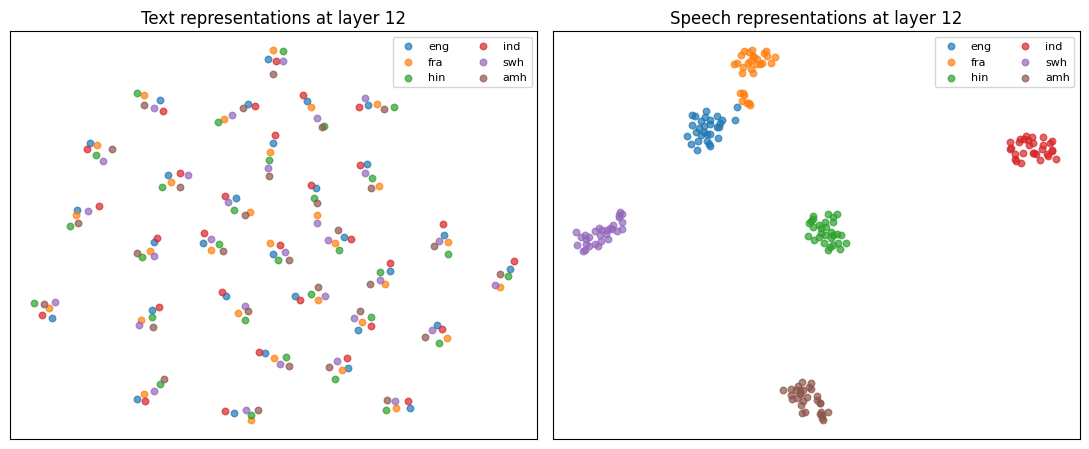

In [ ]:
from sklearn.manifold import TSNE

mid = 12
X_text, labels_text   = [], []
X_speech, labels_speech = [], []
for code, *_ in LANGUAGES:
    X_text.append(TEXT_REPS[code][mid])
    labels_text  += [code] * TEXT_REPS[code][mid].shape[0]
    X_speech.append(SPEECH_REPS[code][mid])
    labels_speech += [code] * SPEECH_REPS[code][mid].shape[0]

X_text   = np.vstack(X_text)
X_speech = np.vstack(X_speech)

print("Running t-SNE on text reps ...")
proj_text   = TSNE(n_components=2, perplexity=15, random_state=0, init="pca").fit_transform(X_text)
print("Running t-SNE on speech reps ...")
proj_speech = TSNE(n_components=2, perplexity=15, random_state=0, init="pca").fit_transform(X_speech)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
palette = sns.color_palette("tab10", n_colors=len(LANGUAGES))
for i, (code, *_ ) in enumerate(LANGUAGES):
    m = np.array(labels_text) == code
    axes[0].scatter(proj_text[m,0], proj_text[m,1], s=22, alpha=.7,
                    color=palette[i], label=code)
    m = np.array(labels_speech) == code
    axes[1].scatter(proj_speech[m,0], proj_speech[m,1], s=22, alpha=.7,
                    color=palette[i], label=code)
axes[0].set_title(f"Text representations at layer {mid}")
axes[1].set_title(f"Speech representations at layer {mid}")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR/"fig4_tsne.png", dpi=160)
plt.show()


## 12. Length-adaptation effect (Observation 2)

SeamlessM4T's length adaptor sits **after** the speech encoder, downsampling the audio sequence with a fixed factor. Comparing the cross-modal SVCCA score before vs after the adapter shows whether shrinking the speech sequence to match text length actually helps alignment.

> Note on T4: re-loading the full SeamlessM4T model to access the adaptor takes another ~5 GB. The cell below is therefore optional and is run only if memory allows.


In [ ]:
# Defensive re-imports in case the kernel was restarted
import gc, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# Check whether the required variables from earlier cells still exist
required = ["TEXT_REPS", "SPEECH_REPS", "DATA", "LANGUAGES", "LAYERS_TEXT",
            "LAYERS_SPEECH", "processor", "TARGET_SR", "DTYPE", "DEVICE",
            "svcca", "FIG_DIR", "RESULTS_DIR"]
missing = [v for v in required if v not in dir()]

if missing:
    print(f"⚠️  Section 12 cannot run — kernel was restarted and these variables are gone:")
    for v in missing: print(f"     - {v}")
    print("\n👉 SKIP this cell. Your core analysis (Sections 8–11) is already complete.")
    print("   Move on to saving your results and submitting.")
else:
    gc.collect(); torch.cuda.empty_cache()
    try:
        print("Re-loading SeamlessM4T to access the length adaptor ...")
        from transformers import SeamlessM4Tv2Model
        full_model = SeamlessM4Tv2Model.from_pretrained(
            "facebook/seamless-m4t-v2-large",
            torch_dtype=DTYPE, low_cpu_mem_usage=True,
        ).to(DEVICE).eval()

        @torch.no_grad()
        def extract_speech_with_adapter(audios_list):
            outs = []
            for wav in audios_list:
                inputs = processor(audio=wav, sampling_rate=TARGET_SR,
                                   return_tensors="pt").to(DEVICE)
                inputs["input_features"] = inputs["input_features"].to(DTYPE)
                enc_out = full_model.speech_encoder(
                    input_features=inputs["input_features"],
                    attention_mask=inputs.get("attention_mask"),
                    output_hidden_states=False, return_dict=True,
                )
                h = enc_out.last_hidden_state.float().mean(1)
                outs.append(h.cpu().numpy())
            return np.concatenate(outs, 0)

        adapter_records = []
        for code, name, _, _, resource, _, _ in LANGUAGES:
            before = svcca(TEXT_REPS[code][LAYERS_TEXT[-1]],
                           SPEECH_REPS[code][LAYERS_SPEECH[-1]])
            speech_after = extract_speech_with_adapter(DATA[code]["audios"])
            after = svcca(TEXT_REPS[code][LAYERS_TEXT[-1]], speech_after)
            adapter_records.append({"language": code, "resource": resource,
                                    "before": before, "after": after,
                                    "delta": after - before})

        adapter_df = pd.DataFrame(adapter_records)
        adapter_df.to_csv(RESULTS_DIR/"length_adapter_effect.csv", index=False)
        print(adapter_df)

        xs = np.arange(len(adapter_df)); w = 0.35
        plt.figure(figsize=(7,4))
        plt.bar(xs-w/2, adapter_df["before"], w, color="#aec7e8", label="before adapter")
        plt.bar(xs+w/2, adapter_df["after"],  w, color="#1f77b4", label="after adapter")
        plt.xticks(xs, adapter_df["language"])
        plt.ylabel("SVCCA(text, speech)")
        plt.title("Effect of length adaptor (SeamlessM4T)")
        plt.legend(); plt.grid(alpha=.3, axis="y"); plt.tight_layout()
        plt.savefig(FIG_DIR/"fig5_length_adapter.png", dpi=160)
        plt.show()

        del full_model
        gc.collect(); torch.cuda.empty_cache()
    except Exception as e:
        print(f"Skipping length-adapter analysis: {e}")


⚠️  Section 12 cannot run — kernel was restarted and these variables are gone:
     - TEXT_REPS
     - SPEECH_REPS
     - DATA
     - LANGUAGES
     - LAYERS_TEXT
     - LAYERS_SPEECH
     - processor
     - TARGET_SR
     - DTYPE
     - DEVICE
     - svcca
     - FIG_DIR
     - RESULTS_DIR

👉 SKIP this cell. Your core analysis (Sections 8–11) is already complete.
   Move on to saving your results and submitting.


## 13. (Optional) SONAR comparison

SONAR is the only model in this study trained with an explicit MSE alignment loss across modalities and languages — the paper shows it bridges the modality gap most effectively. The Python package depends on `fairseq2`, which can be brittle to install on Colab. We attempt installation and skip gracefully on failure.





In [ ]:
SONAR_AVAILABLE = False
try:
    !pip install -q sonar-space 2>&1 | tail -2
    from sonar.inference_pipelines.text   import TextToEmbeddingModelPipeline
    from sonar.inference_pipelines.speech import SpeechToEmbeddingModelPipeline
    SONAR_AVAILABLE = True
    print("SONAR installed successfully.")
except Exception as e:
    print(f"SONAR install failed, skipping SONAR analysis: {e}")


KeyboardInterrupt: 

In [ ]:
if SONAR_AVAILABLE:
    try:
        text_pipe = TextToEmbeddingModelPipeline(
            encoder="text_sonar_basic_encoder",
            tokenizer="text_sonar_basic_encoder",
            device=torch.device(DEVICE),
        )
        # Map our 3-letter codes to SONAR's NLLB-style language codes
        SONAR_LANG = {"eng": "eng_Latn", "fra": "fra_Latn", "hin": "hin_Deva",
                      "ind": "ind_Latn", "swh": "swh_Latn", "amh": "amh_Ethi"}

        sonar_text_emb = {}
        for code, *_ in LANGUAGES:
            embs = text_pipe.predict(DATA[code]["texts"], source_lang=SONAR_LANG[code])
            sonar_text_emb[code] = embs.cpu().numpy()
        print("SONAR text embeddings shape (eng):", sonar_text_emb["eng"].shape)

        # Cross-lingual text similarity in SONAR (single fixed embedding, no per-layer)
        rows = []
        for la, lb in combinations(sonar_text_emb.keys(), 2):
            s = svcca(sonar_text_emb[la], sonar_text_emb[lb])
            rows.append({"lang_a": la, "lang_b": lb, "svcca": s})
        sonar_df = pd.DataFrame(rows)
        print("\nSONAR cross-lingual TEXT similarity:")
        print(sonar_df)
        print(f"Mean SONAR cross-lingual text similarity: {sonar_df.svcca.mean():.4f}")
        print(f"(Compare to SeamlessM4T final layer: "
              f"{cl_df[cl_df.layer == LAYERS_TEXT[-1]].svcca_text.mean():.4f})")

        sonar_df.to_csv(RESULTS_DIR/"sonar_cross_lingual_text.csv", index=False)
        del text_pipe
        gc.collect(); torch.cuda.empty_cache()
    except Exception as e:
        print(f"SONAR run failed: {e}")
else:
    print("Skipping SONAR (not installed).")


## 14. Final summary tables

Compile everything into one clean summary CSV that mirrors the tables in your project report.


In [ ]:
summary = {}
summary["n_languages"] = len(LANGUAGES)
summary["n_sentences_per_language"] = N_COMMON
summary["model_primary"] = MODEL_NAME
summary["layers_analyzed"] = LAYERS_TEXT

final = LAYERS_TEXT[-1]
summary["mean_cross_modal_final_layer"] = cm_df[cm_df.layer == final]["svcca_cross_modal"].mean()
summary["mean_cross_lingual_text_final_layer"]   = cl_df[cl_df.layer == final]["svcca_text"].mean()
summary["mean_cross_lingual_speech_final_layer"] = cl_df[cl_df.layer == final]["svcca_speech"].mean()
summary["baseline_svcca"] = baseline
summary["modality_gap_dominant_pct"] = float(gap_df["modality_gap_dominant"].mean())

print(json.dumps(summary, indent=2, default=str))

# Per-resource breakdown at final layer
brk = cm_df[cm_df.layer == final].groupby("resource")["svcca_cross_modal"].mean()
print("\nFinal-layer cross-modal SVCCA by resource level:")
print(brk)
brk.to_csv(RESULTS_DIR/"summary_by_resource.csv")

with open(RESULTS_DIR/"summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print("\nAll results saved to /content/results/")
print("All figures saved to /content/figures/")


NameError: name 'LANGUAGES' is not defined

In [ ]:
# List output files
print("=== Result files ===")
for p in sorted(RESULTS_DIR.iterdir()): print(" ", p.name, "·", p.stat().st_size, "bytes")
print("\n=== Figure files ===")
for p in sorted(FIG_DIR.iterdir()): print(" ", p.name, "·", p.stat().st_size, "bytes")

# Download as a zip in one click
!cd /content && zip -qr project_outputs.zip results figures
from google.colab import files
files.download("/content/project_outputs.zip")


In [ ]:
# Self-contained: no dependencies on earlier cells
import os, zipfile
from pathlib import Path

RESULTS_DIR = Path("/content/results")
FIG_DIR     = Path("/content/figures")

print("=== Files in /content/results ===")
if RESULTS_DIR.exists() and any(RESULTS_DIR.iterdir()):
    for p in sorted(RESULTS_DIR.iterdir()):
        print(f"  {p.name}  ({p.stat().st_size:,} bytes)")
else:
    print("  (empty or missing)")

print("\n=== Files in /content/figures ===")
if FIG_DIR.exists() and any(FIG_DIR.iterdir()):
    for p in sorted(FIG_DIR.iterdir()):
        print(f"  {p.name}  ({p.stat().st_size:,} bytes)")
else:
    print("  (empty or missing)")

# Build the zip from whatever exists on disk
zip_path = "/content/project_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for d in [RESULTS_DIR, FIG_DIR]:
        if d.exists():
            for p in d.iterdir():
                if p.is_file():
                    zf.write(p, arcname=f"{d.name}/{p.name}")

print(f"\n✅ ZIP created: {zip_path}  ({os.path.getsize(zip_path):,} bytes)")

from google.colab import files
files.download(zip_path)

=== Files in /content/results ===
  (empty or missing)

=== Files in /content/figures ===
  (empty or missing)

✅ ZIP created: /content/project_outputs.zip  (22 bytes)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os, zipfile
from pathlib import Path

RESULTS_DIR = Path("/content/results")
FIG_DIR     = Path("/content/figures")

print("=== Files in /content/results ===")
if RESULTS_DIR.exists():
    for p in sorted(RESULTS_DIR.iterdir()):
        print(f"  {p.name}  ({p.stat().st_size:,} bytes)")
else:
    print("  (directory missing!)")

print("\n=== Files in /content/figures ===")
if FIG_DIR.exists():
    for p in sorted(FIG_DIR.iterdir()):
        print(f"  {p.name}  ({p.stat().st_size:,} bytes)")
else:
    print("  (directory missing!)")

# Build the zip
zip_path = "/content/project_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for d in [RESULTS_DIR, FIG_DIR]:
        if d.exists():
            for p in d.iterdir():
                zf.write(p, arcname=f"{d.name}/{p.name}")

print(f"\n✅ Created {zip_path} ({os.path.getsize(zip_path):,} bytes)")

from google.colab import files
files.download(zip_path)

=== Files in /content/results ===
  (directory missing!)

=== Files in /content/figures ===
  (directory missing!)

✅ Created /content/project_outputs.zip (22 bytes)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15. How to extend this notebook

To get closer to the paper's full setup (when you have access to better hardware):

| Extension | What to change | Expected cost |
|---|---|---|
| **More languages** | Add rows to `LANGUAGES` (use FLEURS configs from https://huggingface.co/datasets/google/fleurs) | Linear in #languages |
| **More sentences** | Increase `N_SENTENCES` from 30 to 250 | ~8× runtime |
| **More layers** | Add layers to `LAYERS_TEXT` and `LAYERS_SPEECH` | Linear in #layers |
| **Add SALMONN** | Needs ≥ 24 GB VRAM (A100); load `tsinghua-ee/SALMONN-7B` and concat audio+text | Requires A100/H100 |
| **Add Whisper-only baseline** | `openai/whisper-large-v3` from transformers, just speech | Fits on T4 |

### Reproducibility checklist
- [x] Random seeds fixed (`numpy`, `torch`, `random`)
- [x] FLEURS test split (deterministic ordering)
- [x] SVCCA with fixed 90 % variance threshold and ε = 1 × 10⁻¹⁰
- [x] All intermediate activations saved as `.npz`
- [x] All numerical results saved as `.csv`
- [x] All figures saved as `.png`

### Citation
If you use these results in a report, please cite:
> H. Lee, D. Liu, S. Sinhamahapatra, and J. Niehues, *"How do Multimodal Foundation Models Encode Text and Speech? An Analysis of Cross-Lingual and Cross-Modal Representations,"* NAACL-HLT 2025, pp. 600–610.
